In [1]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt


In [2]:
# -------------------------------------------------
# Create FrozenLake Environment
# -------------------------------------------------

env = gym.make("FrozenLake-v1", is_slippery=True)

n_states = env.observation_space.n
n_actions = env.action_space.n

print("Number of states:", n_states)
print("Number of actions:", n_actions)

Number of states: 16
Number of actions: 4


In [3]:
# -------------------------------------------------
# Hyperparameters
# -------------------------------------------------

alpha = 0.8          # Learning rate
gamma = 0.95         # Discount factor
epsilon = 1.0        # Initial exploration rate
epsilon_min = 0.01   # Minimum exploration rate
epsilon_decay = 0.995
episodes = 10000
max_steps = 100

In [4]:
# -------------------------------------------------
# Initialize Q-table
# -------------------------------------------------

Q = np.zeros((n_states, n_actions))

episode_rewards = []

# Epsilon-Greedy Action Selection
# -------------------------------------------------

def choose_action(state, epsilon):
    if np.random.random() < epsilon:
        return env.action_space.sample()
    else:
        return np.argmax(Q[state])


In [5]:
# -------------------------------------------------
# Q-Learning Training
# -------------------------------------------------

for episode in range(episodes):

    state, info = env.reset()
    total_reward = 0

    for step in range(max_steps):

        # Select action using epsilon-greedy strategy
        action = choose_action(state, epsilon)

        # Take action
        next_state, reward, terminated, truncated, info = env.step(action)

        # Q-Learning update
        best_next_action = np.max(Q[next_state])

        Q[state, action] = Q[state, action] + alpha * (
            reward + gamma * best_next_action - Q[state, action]
        )

        state = next_state
        total_reward += reward

        # Stop if episode ends
        if terminated or truncated:
            break

    episode_rewards.append(total_reward)

    # Reduce epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)

print("Training completed!")
print("Final epsilon:", epsilon)

Training completed!
Final epsilon: 0.01


In [6]:
# -------------------------------------------------
# Calculate State Values and Learned Policy
# -------------------------------------------------

state_values = np.max(Q, axis=1)
learned_policy = np.argmax(Q, axis=1)

In [7]:
# -------------------------------------------------
# Display Functions
# -------------------------------------------------

def print_value_function(values):
    print("\nEstimated State-Value Function:")
    print(np.round(values.reshape(4, 4), 3))


def print_policy(policy):
    action_symbols = {
        0: "L",
        1: "D",
        2: "R",
        3: "U"
    }

    policy_grid = np.array(
        [action_symbols[action] for action in policy]
    ).reshape(4, 4)

    print("\nLearned Policy:")
    print(policy_grid)


In [8]:
# -------------------------------------------------
# Output
# -------------------------------------------------

print("\nFinal Q-table:")
print(np.round(Q, 3))

print_value_function(state_values)
print_policy(learned_policy)

average_reward = np.mean(episode_rewards[-1000:])
print("\nAverage reward over last 1000 episodes:", average_reward)


Final Q-table:
[[0.081 0.074 0.061 0.063]
 [0.005 0.011 0.009 0.03 ]
 [0.008 0.032 0.003 0.011]
 [0.001 0.006 0.002 0.043]
 [0.101 0.048 0.033 0.011]
 [0.    0.    0.    0.   ]
 [0.53  0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.03  0.002 0.011 0.51 ]
 [0.005 0.772 0.018 0.04 ]
 [0.816 0.001 0.005 0.007]
 [0.    0.    0.    0.   ]
 [0.    0.    0.    0.   ]
 [0.048 0.032 0.329 0.015]
 [0.148 0.973 0.15  0.132]
 [0.    0.    0.    0.   ]]

Estimated State-Value Function:
[[0.081 0.03  0.032 0.043]
 [0.101 0.    0.53  0.   ]
 [0.51  0.772 0.816 0.   ]
 [0.    0.329 0.973 0.   ]]

Learned Policy:
[['L' 'U' 'D' 'U']
 ['L' 'L' 'L' 'L']
 ['U' 'D' 'L' 'L']
 ['L' 'R' 'D' 'L']]

Average reward over last 1000 episodes: 0.557


Name : HARINI S
REG NO : 212223240048


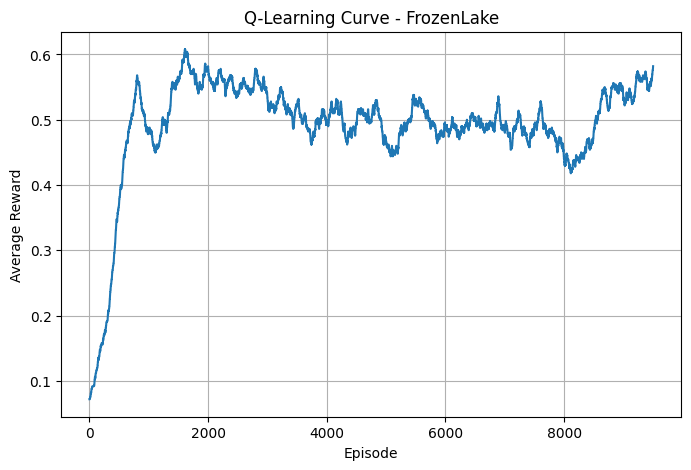

In [10]:
# -------------------------------------------------
# Plot Learning Curve
# -------------------------------------------------

window = 500

moving_average = np.convolve(
    episode_rewards,
    np.ones(window) / window,
    mode="valid"
)
print("Name : HARINI S")
print("REG NO : 212223240048")
plt.figure(figsize=(8, 5))
plt.plot(moving_average)
plt.xlabel("Episode")
plt.ylabel("Average Reward")
plt.title("Q-Learning Curve - FrozenLake")
plt.grid(True)
plt.show()

env.close()